In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv("../data/CC GENERAL.csv")

print("Shape:", df.shape)

In [ ]:
print(df.isnull().sum())

df.drop('CUST_ID', axis=1, inplace=True)

df.fillna(df.mean(), inplace=True)

df.info()

In [11]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [ ]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_data)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_data, labels))

# Plot Elbow
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")

# Plot Silhouette
plt.subplot(1,2,2)
plt.plot(K_range, silhouette_scores, marker='o')
plt.title("Silhouette Score")

plt.show()

In [13]:
k = 4  # chosse from plot

kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

df['Cluster'] = clusters

In [14]:
pca = PCA(n_components=0.95)
pca_data = pca.fit_transform(scaled_data)

print("Reduced Dimensions:", pca_data.shape)

Reduced Dimensions: (8950, 12)


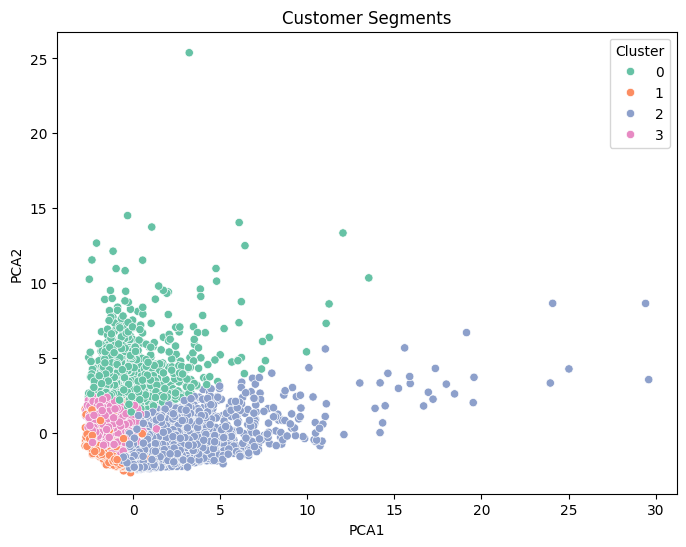

             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                                  
0        5023.958508           0.967107   721.184928        453.485000   
1         109.464707           0.412883   351.589913        191.487250   
2        1253.422099           0.974766  2181.418772       1241.370362   
3        1500.348531           0.966640   282.216074        209.226223   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                    267.804742   5075.737329             0.329511   
1                    160.571811    299.684391             0.320703   
2                    940.311888    234.489319             0.928436   
3                     73.305481    789.088912             0.206247   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster                                                      

In [ ]:
# 2D PCA for visualization
pca_2d = PCA(n_components=2)
pca_2d_data = pca_2d.fit_transform(scaled_data)

df['PCA1'] = pca_2d_data[:,0]
df['PCA2'] = pca_2d_data[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set2')
plt.title("Customer Segments")
plt.show()

# Cluster insights
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)

"""
Customer Segments Insights:

Cluster 0:
- High balance and high purchases
- These are high-value customers
- Strategy: Offer premium services and rewards

Cluster 1:
- Low activity and low spending
- These are low engagement customers
- Strategy: Target with marketing campaigns

Cluster 2:
- Frequent transactions but moderate spending
- Regular customers
- Strategy: Retain with loyalty programs

Cluster 3:
- High balance but low payments
- Potential risky customers
- Strategy: Monitor and offer financial planning support
"""